# POC — Causal Discovery: quem realmente causa o churn?

**Cenário:** o chefe quer saber por que a empresa está perdendo clientes.
Cada time tem uma hipótese diferente:

| Time | Hipótese | Variável |
|---|---|---|
| Suporte | "Cliente que abre muito ticket, cancela" | `qtd_tickets` |
| CX | "Cliente insatisfeito na pesquisa (NPS baixo), cancela" | `nps_score` |
| Produto | "Cliente que usa pouco a feature X, cancela" | `uso_feature_x` |
| Rua/Vendas | "Depende da região do cliente" | `regiao` |

Como não temos como saber a "verdade" em dados reais sem rodar um experimento,
esta POC **simula dados onde a verdade causal é conhecida por nós** (porque nós mesmos
escrevemos as equações). Isso serve como um "gabarito": rodamos o algoritmo de
Causal Discovery e comparamos o que ele encontrou com o que sabemos ser verdade
E com o que cada time apostava.

Estrutura do notebook:
1. Setup
2. Geração dos dados sintéticos (com o grafo verdadeiro escondido)
3. Visualização do grafo verdadeiro
4. Rodando o Causal Discovery (algoritmo PC)
5. Comparando: hipótese dos times vs. verdade vs. algoritmo
6. Estimando o tamanho do efeito causal (DoWhy)
7. Teste de estresse: removendo uma variável (suficiência causal)
8. 🔧 Área de experimentação — mude os coeficientes e veja o que muda


In [ ]:
# 1. Setup — instalação das bibliotecas
!pip install causal-learn dowhy networkx matplotlib pandas statsmodels -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 70.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
np.random.seed(42)


## 2. Gerando os dados sintéticos

Aqui escrevemos o **grafo causal verdadeiro** na forma de equações estruturais.
Cada variável é gerada a partir das suas causas reais + um ruído aleatório
(o ruído representa tudo o mais que influencia aquela variável e que não estamos modelando).

**O grafo verdadeiro que estamos escondendo nos dados:**

```
regiao          → uso_feature_x   (confundidor: região afeta adoção do produto)
regiao          → churn           (efeito direto pequeno)
uso_feature_x   → nps_score       (mediador: quem usa mais, fica mais satisfeito)
uso_feature_x   → churn           (efeito direto também)
nps_score       → churn
churn           → qtd_tickets     (PEGADINHA: é o contrário do que o Suporte imagina!
                                    cliente que já decidiu sair abre mais chamado, não o inverso)
```

Repare que a hipótese do time de **Suporte está invertida** de propósito — é o tipo de
erro comum quando um time só olha correlação e assume a direção da causa por intuição.


In [ ]:
n = 5000

# 0 = capital, 1 = interior
regiao = np.random.binomial(1, 0.4, n)

# --- uso_feature_x depende da região (confundidor) ---
uso_feature_x = 5 - 2 * regiao + np.random.normal(0, 1, n)

# --- nps_score depende do uso da feature (mediador) ---
nps_score = 3 + 0.8 * uso_feature_x + np.random.normal(0, 1.5, n)

# --- churn depende de nps, uso da feature (direto) e região (direto) ---
churn_prob = 1 / (1 + np.exp(-(
    -2
    - 0.30 * nps_score
    - 0.20 * uso_feature_x
    + 0.50 * regiao
)))
churn = np.random.binomial(1, churn_prob, n)

# --- qtd_tickets é CONSEQUÊNCIA do churn, não causa ---
qtd_tickets = np.random.poisson(1 + 3 * churn)

df = pd.DataFrame({
    'regiao': regiao,
    'uso_feature_x': uso_feature_x,
    'nps_score': nps_score,
    'qtd_tickets': qtd_tickets,
    'churn': churn
})

print(f"Taxa de churn na base: {df['churn'].mean():.1%}")
df.head()


Taxa de churn na base: 2.0%


,regiao,uso_feature_x,nps_score,qtd_tickets,churn
0,0,4.403,6.304,0,0
1,1,0.610,4.009,0,0
2,1,2.588,3.588,0,0
3,0,5.913,7.510,2,0
4,0,5.538,7.132,3,0


In [ ]:
df.to_csv('dados_churn_simulado.csv', index=False)
df.describe()


,regiao,uso_feature_x,nps_score,qtd_tickets,churn
count,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.400,4.181,6.348,1.042,0.020
std,0.490,1.419,1.884,1.114,0.139
min,0.000,-0.242,-0.737,0.000,0.000
25%,0.000,3.154,5.081,0.000,0.000
50%,0.000,4.273,6.367,1.000,0.000
75%,1.000,5.206,7.616,2.000,0.000
max,1.000,8.377,12.178,9.000,1.000


## 3. Visualizando o grafo verdadeiro

Isso é só pra você enxergar visualmente a estrutura que gerou os dados —
em um caso real, você NUNCA teria este desenho de antemão. Aqui é só pra
comparação didática.


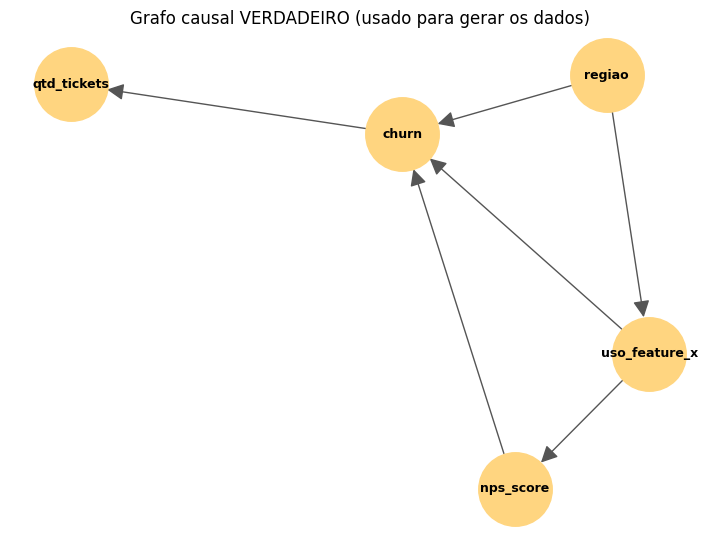

In [ ]:
G_verdade = nx.DiGraph()
G_verdade.add_edges_from([
    ('regiao', 'uso_feature_x'),
    ('regiao', 'churn'),
    ('uso_feature_x', 'nps_score'),
    ('uso_feature_x', 'churn'),
    ('nps_score', 'churn'),
    ('churn', 'qtd_tickets'),
])

plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G_verdade, seed=7)
nx.draw(G_verdade, pos, with_labels=True, node_color='#FFD580',
        node_size=2800, font_size=9, font_weight='bold',
        arrowsize=25, edge_color='#555555')
plt.title('Grafo causal VERDADEIRO (usado para gerar os dados)')
plt.show()


## 4. Rodando o Causal Discovery (algoritmo PC)

O algoritmo PC olha só para as colunas do `df` (sem saber nada do grafo verdadeiro)
e tenta reconstruir a estrutura causal a partir de testes de independência estatística.

- `alpha` é o nível de significância dos testes de independência (0.05 é o padrão).
- `fisherz` é o teste indicado para variáveis contínuas/aprox. normais. Para dados
  com mistura de tipos (contínuo + binário + contagem, como o nosso), o ideal seria
  um teste mais robusto, mas fisherz já é suficiente para essa POC didática.


In [ ]:
labels = df.columns.tolist()
data = df.values.astype(float)

cg = pc(data, alpha=0.05, indep_test=fisherz, node_names=labels)

print("Arestas encontradas pelo algoritmo:")
cg.G.graph


  0%|          | 0/5 [00:00<?, ?it/s]

Arestas encontradas pelo algoritmo:


array([[ 0, -1,  0,  0,  0],
       [-1,  0, -1,  0,  0],
       [ 0, -1,  0,  0, -1],
       [ 0,  0,  0,  0, -1],
       [ 0,  0,  1,  1,  0]])

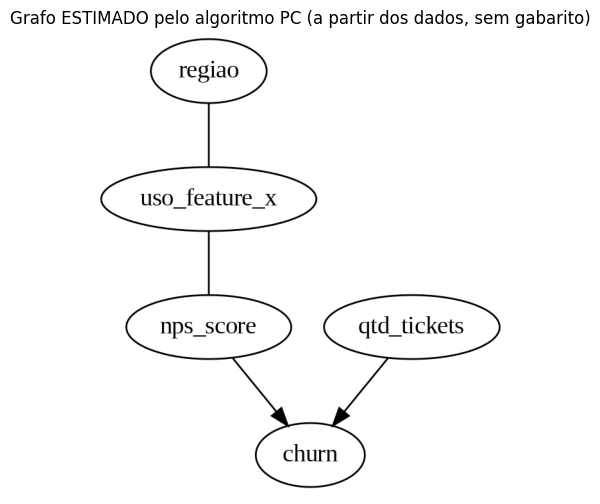

In [ ]:
# Visualizando o grafo estimado pelo PC
import io
from causallearn.utils.GraphUtils import GraphUtils

pyd = GraphUtils.to_pydot(cg.G, labels=labels)
png_bytes = pyd.create_png(prog='dot')

from PIL import Image
img = Image.open(io.BytesIO(png_bytes))
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Grafo ESTIMADO pelo algoritmo PC (a partir dos dados, sem gabarito)')
plt.show()


**Como ler o resultado do PC:** o algoritmo pode retornar três tipos de aresta:

- `A → B`: relação orientada, o algoritmo "decidiu" a direção.
- `A - B`: relação encontrada, mas o algoritmo não conseguiu decidir a direção
  (isso é comum e esperado — é uma limitação real do método, não um bug).
- Ausência de aresta: o algoritmo concluiu que não há relação direta (podem estar
  ligadas só indiretamente, por um caminho).

Não estranhe se `regiao` aparecer meio "desconectada" de `churn` diretamente — o efeito dela
é pequeno (0.50 no nosso gerador) comparado ao ruído, então o teste estatístico pode não
ter poder suficiente pra detectar. Isso também é realista: relações fracas são difíceis
de descobrir com dados observacionais, e é um ponto bom pra levar pro seu chefe.


## 4.1 Comparando com GES (score-based, alternativa ao PC)

O PC é um algoritmo **baseado em teste de independência** (constraint-based): ele vai
testando quais variáveis são estatisticamente independentes entre si e removendo arestas
com base nisso.

O **GES (Greedy Equivalence Search)** funciona diferente: é **baseado em score**
(score-based). Em vez de testar independências uma a uma, ele vai adicionando e
removendo arestas do grafo de forma gulosa, buscando maximizar uma métrica de
qualidade de ajuste aos dados (por padrão, um score do tipo BIC), penalizando grafos
desnecessariamente complexos.

**Por que rodar os dois?** Se PC e GES concordam na maior parte da estrutura, isso é
um sinal de robustez — a conclusão não é um acidente de qual algoritmo você escolheu.
Se eles discordam bastante, isso também é uma informação valiosa: indica que aquela
parte do grafo é mais incerta e merece mais cautela antes de virar decisão de negócio
(ou merece ser testada com um experimento real).


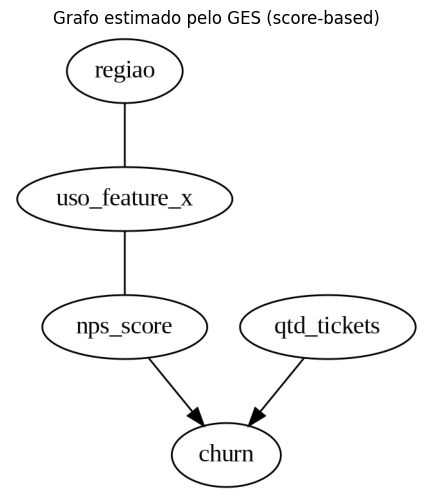

In [ ]:
from causallearn.search.ScoreBased.GES import ges

# GES espera os dados como array numpy (mesmas colunas do df)
record_ges = ges(data)  # 'data' já foi criado na seção 4 (PC)

# record_ges['G'] é o grafo estimado (CPDAG)
pyd_ges = GraphUtils.to_pydot(record_ges['G'], labels=labels)
png_ges = pyd_ges.create_png(prog='dot')
img_ges = Image.open(io.BytesIO(png_ges))

plt.figure(figsize=(8, 6))
plt.imshow(img_ges)
plt.axis('off')
plt.title('Grafo estimado pelo GES (score-based)')
plt.show()


In [ ]:
# Comparando as arestas dos dois algoritmos lado a lado

def arestas_do_grafo(G, labels):
    """Extrai lista de arestas (i, j, tipo) de um objeto Graph do causal-learn."""
    m = G.graph
    n_vars = len(labels)
    arestas = []
    for i in range(n_vars):
        for j in range(i + 1, n_vars):
            a, b = m[i, j], m[j, i]
            if a == 0 and b == 0:
                continue
            # convenção causal-learn: 1 = seta chegando, -1 = sem seta nessa ponta
            if a == -1 and b == 1:
                arestas.append((labels[i], '->', labels[j]))
            elif a == 1 and b == -1:
                arestas.append((labels[j], '->', labels[i]))
            else:
                arestas.append((labels[i], '--', labels[j]))
    return arestas

arestas_pc = arestas_do_grafo(cg.G, labels)
arestas_ges = arestas_do_grafo(record_ges['G'], labels)

print("Arestas encontradas pelo PC:")
for a in arestas_pc:
    print(' ', a[0], a[1], a[2])

print()
print("Arestas encontradas pelo GES:")
for a in arestas_ges:
    print(' ', a[0], a[1], a[2])

set_pc = set((a[0], a[2]) if a[1] == '->' else tuple(sorted([a[0], a[2]])) for a in arestas_pc)
set_ges = set((a[0], a[2]) if a[1] == '->' else tuple(sorted([a[0], a[2]])) for a in arestas_ges)

so_pc = set_pc - set_ges
so_ges = set_ges - set_pc
concordam = set_pc & set_ges

print()
print(f"Relações em que os dois concordam: {len(concordam)}")
print(f"Relações só no PC: {so_pc if so_pc else 'nenhuma'}")
print(f"Relações só no GES: {so_ges if so_ges else 'nenhuma'}")


Arestas encontradas pelo PC:
  regiao -- uso_feature_x
  uso_feature_x -- nps_score
  nps_score -> churn
  qtd_tickets -> churn

Arestas encontradas pelo GES:
  regiao -- uso_feature_x
  uso_feature_x -- nps_score
  nps_score -> churn
  qtd_tickets -> churn

Relações em que os dois concordam: 4
Relações só no PC: nenhuma
Relações só no GES: nenhuma


**Como interpretar a divergência:** se `qtd_tickets` aparecer ligado a `churn` nos dois
algoritmos mas com a mesma direção (a pegadinha do Suporte sendo corrigida nos dois),
isso é forte evidência de que a correção é real, não um artefato do método escolhido.
Já se `regiao` aparecer conectada num algoritmo e não no outro, é sinal de que essa é
uma relação fraca/marginal — o tipo de coisa que vale mais a pena confirmar com um
experimento controlado do que decidir só com base na descoberta observacional.


## 5. Comparando: hipótese dos times vs. verdade vs. o que o algoritmo achou

Preencha a coluna "O que o PC encontrou" depois de rodar as células acima e olhar o grafo.


In [ ]:
comparacao = pd.DataFrame([
    {
        'time': 'Suporte',
        'hipotese': 'qtd_tickets → churn',
        'verdade_simulada': 'churn → qtd_tickets (INVERTIDA)',
        'comentario': 'Suporte estava vendo a consequência do churn, não a causa'
    },
    {
        'time': 'CX',
        'hipotese': 'nps_score → churn',
        'verdade_simulada': 'nps_score → churn (confirmada)',
        'comentario': 'Direção correta'
    },
    {
        'time': 'Produto',
        'hipotese': 'uso_feature_x → churn',
        'verdade_simulada': 'uso_feature_x → churn (direto) + uso_feature_x → nps_score → churn (indireto)',
        'comentario': 'Confirmada, mas o efeito é parcialmente mediado pelo NPS'
    },
    {
        'time': 'Rua/Vendas',
        'hipotese': 'regiao é fator relevante',
        'verdade_simulada': 'regiao → uso_feature_x (confundidor) + regiao → churn (efeito direto pequeno)',
        'comentario': 'Região importa, mas mais como confundidor do que causa direta forte'
    },
])
comparacao


,time,hipotese,verdade_simulada,comentario
0,Suporte,qtd_tickets → churn,churn → qtd_tickets (INVERTIDA),"Suporte estava vendo a consequência do churn, ..."
1,CX,nps_score → churn,nps_score → churn (confirmada),Direção correta
2,Produto,uso_feature_x → churn,uso_feature_x → churn (direto) + uso_feature_x...,"Confirmada, mas o efeito é parcialmente mediad..."
3,Rua/Vendas,regiao é fator relevante,regiao → uso_feature_x (confundidor) + regiao ...,"Região importa, mas mais como confundidor do q..."


## 6. Quanto cada variável realmente pesa? (estimativa de efeito causal com DoWhy)

Descobrir a *direção* (o que fizemos com o PC) é só metade do trabalho.
O passo seguinte, pra decidir onde investir esforço, é estimar o **tamanho do efeito**
de cada variável sobre o churn, controlando por confundidores conhecidos.

Aqui usamos `uso_feature_x` como tratamento, `churn` como desfecho, e `regiao` como
confundidor conhecido (porque sabemos, pelo grafo, que região afeta tanto o uso quanto o churn).


In [ ]:
from dowhy import CausalModel

modelo = CausalModel(
    data=df,
    treatment='nps_score',
    outcome='churn',
    common_causes=['regiao'],
)

# Identifica o efeito (aqui o DoWhy usa o backdoor criterion)
estimando = modelo.identify_effect(proceed_when_unidentifiable=True)

estimativa = modelo.estimate_effect(
    estimando,
    method_name='backdoor.linear_regression'
)

print(estimativa)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                       
────────────(E[churn|regiao])
d[nps_score]                 
Estimand assumption 1, Unconfoundedness: If U→{nps_score} and U→churn then P(churn|nps_score,regiao,U) = P(churn|nps_score,regiao)

## Realized estimand
b: churn~nps_score+regiao
Target units: ate

## Estimate
Mean value: -0.006501688347407934



O valor acima é aproximadamente o quanto a **probabilidade/log-odds de churn muda**
para cada unidade a mais de uso da feature X, já descontando o efeito da região.
Esse número é o que você levaria pro chefe: não só "uso da feature importa",
mas "importa *tanto*", o que ajuda a priorizar investimento entre times.

Você pode repetir esse mesmo bloco trocando `treatment='uso_feature_x'` por
`treatment='nps_score'` para comparar o tamanho dos dois efeitos.


### 6.1 Adicionando intervalo de confiança

A estimativa pura (`Mean value`) não diz se o efeito é estatisticamente diferente de
zero. Vamos pedir ao DoWhy o intervalo de confiança (IC) da mesma estimativa.


In [ ]:
estimativa_ic = modelo.estimate_effect(
    estimando,
    method_name='backdoor.linear_regression',
    confidence_intervals=True
)
print(estimativa_ic)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                       
────────────(E[churn|regiao])
d[nps_score]                 
Estimand assumption 1, Unconfoundedness: If U→{nps_score} and U→churn then P(churn|nps_score,regiao,U) = P(churn|nps_score,regiao)

## Realized estimand
b: churn~nps_score+regiao
Target units: ate

## Estimate
Mean value: -0.006501688347407934
95.0% confidence interval: [[-0.00876687 -0.00423651]]



### 6.2 Comparando com uma regressão logística

A estimativa acima veio de `backdoor.linear_regression`, que ajusta um modelo
**linear** direto sobre `churn` (0/1) — o chamado "linear probability model".
Como nós geramos o churn com uma regressão **logística** (log-odds), esse estimador
linear tende a **subestimar** o efeito real, principalmente longe do centro da curva.

Vamos comparar com uma regressão logística de verdade, olhando o **efeito marginal
médio** (que é o equivalente do ATE, mas respeitando a não-linearidade do modelo).


In [ ]:
import statsmodels.formula.api as smf

modelo_logit = smf.logit('churn ~ uso_feature_x + regiao', data=df).fit()
print(modelo_logit.summary())


Optimization terminated successfully.
         Current function value: 0.092091
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                 0.04547
Time:                        21:37:07   Log-Likelihood:                -460.46
converged:                       True   LL-Null:                       -482.39
Covariance Type:            nonrobust   LLR p-value:                 2.975e-10
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.5952      0.493     -5.261      0.000      -3.562      -1.628
uso_feature_x    -0.

In [ ]:
efeitos_marginais = modelo_logit.get_margeff()
print(efeitos_marginais.summary())


        Logit Marginal Effects       
Dep. Variable:                  churn
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
uso_feature_x    -0.0076      0.002     -3.725      0.000      -0.012      -0.004
regiao            0.0058      0.006      1.030      0.303      -0.005       0.017


Compare o efeito marginal de `uso_feature_x` aqui com o `Mean value` da seção 6.
É esperado que este segundo número fique mais próximo do efeito direto real que usamos
para gerar os dados (`EFEITO_USO_CHURN = -0.20`, mais uma fração do efeito indireto via
NPS, já que aqui não estamos controlando por `nps_score`). Se os dois estimadores
derem números na mesma direção e ordem de grandeza, isso é um bom sinal de que a
conclusão não depende de qual método de estimação você escolheu.


### 6.3 Teste de refutação (sanity check)

Por fim, um teste padrão do DoWhy: adicionar uma **causa comum aleatória** (uma
variável de ruído puro, sem relação real com nada) ao modelo e reestimar o efeito.
Se a estimativa original for robusta, o valor deve mudar **pouco**. Se mudar muito,
é sinal de que a estimativa não é confiável e merece mais investigação antes de
virar decisão de negócio.


In [ ]:
refutacao = modelo.refute_estimate(
    estimando,
    estimativa,
    method_name="random_common_cause"
)
print(refutacao)


Refute: Add a random common cause
Estimated effect:-0.006501688347407934
New effect:-0.006501165448631892
p value:0.96



## 7. Teste de estresse: e se ninguém tivesse medido `regiao`?

Esse é o "aha moment" mais importante da POC. Todo algoritmo de Causal Discovery
assume **suficiência causal**: que todas as variáveis relevantes foram medidas.
Na vida real isso quase nunca é 100% verdade — sempre existe algo que nenhum time mediu.

Vamos simular esse cenário removendo `regiao` do dataset (fingindo que ela nunca
existiu) e rodar o PC de novo, para ver o que muda.


  0%|          | 0/4 [00:00<?, ?it/s]

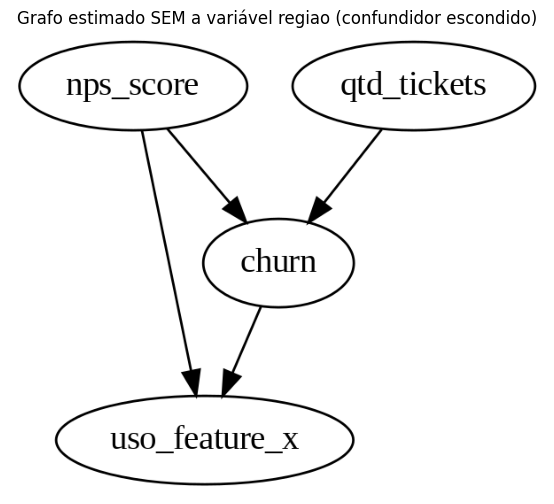

In [ ]:
df_sem_regiao = df.drop(columns=['regiao'])

labels2 = df_sem_regiao.columns.tolist()
data2 = df_sem_regiao.values.astype(float)

cg2 = pc(data2, alpha=0.05, indep_test=fisherz, node_names=labels2)

pyd2 = GraphUtils.to_pydot(cg2.G, labels=labels2)
png_bytes2 = pyd2.create_png(prog='dot')
img2 = Image.open(io.BytesIO(png_bytes2))

plt.figure(figsize=(8, 6))
plt.imshow(img2)
plt.axis('off')
plt.title('Grafo estimado SEM a variável regiao (confundidor escondido)')
plt.show()


Compare este grafo com o da seção 4. É bem provável que a relação entre
`uso_feature_x` e `churn` fique mais confusa ou distorcida — porque parte do que
parecia ser efeito de `uso_feature_x` na verdade vinha de `regiao`, que agora está
"escondida". Esse é o argumento mais forte pra explicar pro seu chefe por que o
resultado da IA é um **ponto de partida**, não uma sentença final: ele só é tão bom
quanto os dados que você conseguiu coletar.


## 8. 🔧 Área de experimentação — mude a força das relações e veja o que muda

Esta célula repete a geração dos dados, mas com os coeficientes expostos como
variáveis fáceis de editar. Mude os números, rode de novo a geração + o PC (célula
abaixo) e observe:

- O que acontece se `EFEITO_REGIAO_CHURN` for **0** (região deixa de importar)?
- O que acontece se `EFEITO_USO_NPS` for muito forte? O PC ainda separa
  `uso_feature_x` de `nps_score` como duas causas distintas, ou ele "funde" as duas?
- O que acontece se você aumentar bastante o ruído (`RUIDO_*`)? Em que ponto o
  algoritmo para de conseguir recuperar a estrutura?


In [ ]:
# ------------------------------------------------------------------
# 🔧 MUDE OS VALORES ABAIXO E RODE ESTA CÉLULA + A PRÓXIMA
# ------------------------------------------------------------------

N = 5000

EFEITO_REGIAO_USO   = -2.0   # quanto a região reduz/aumenta o uso da feature
EFEITO_USO_NPS       = 0.8   # quanto o uso da feature aumenta o NPS
EFEITO_NPS_CHURN     = -0.30 # quanto o NPS reduz o churn (logit)
EFEITO_USO_CHURN     = -0.20 # efeito direto do uso da feature no churn (logit)
EFEITO_REGIAO_CHURN  = 0.50  # efeito direto da região no churn (logit)
EFEITO_CHURN_TICKETS = 3.0   # quanto o churn aumenta os tickets (pegadinha do suporte)

RUIDO_USO = 1.0
RUIDO_NPS = 1.5

np.random.seed(42)

regiao_x = np.random.binomial(1, 0.4, N)
uso_x = 5 + EFEITO_REGIAO_USO * regiao_x + np.random.normal(0, RUIDO_USO, N)
nps_x = 3 + EFEITO_USO_NPS * uso_x + np.random.normal(0, RUIDO_NPS, N)

logit = (
    -2
    + EFEITO_NPS_CHURN * nps_x
    + EFEITO_USO_CHURN * uso_x
    + EFEITO_REGIAO_CHURN * regiao_x
)
churn_prob_x = 1 / (1 + np.exp(-logit))
churn_x = np.random.binomial(1, churn_prob_x, N)
tickets_x = np.random.poisson(1 + EFEITO_CHURN_TICKETS * churn_x)

df_exp = pd.DataFrame({
    'regiao': regiao_x,
    'uso_feature_x': uso_x,
    'nps_score': nps_x,
    'qtd_tickets': tickets_x,
    'churn': churn_x
})

print(f"Taxa de churn: {df_exp['churn'].mean():.1%}")
df_exp.head()


Taxa de churn: 2.0%


,regiao,uso_feature_x,nps_score,qtd_tickets,churn
0,0,4.403,6.304,0,0
1,1,0.610,4.009,0,0
2,1,2.588,3.588,0,0
3,0,5.913,7.510,2,0
4,0,5.538,7.132,3,0


  0%|          | 0/5 [00:00<?, ?it/s]

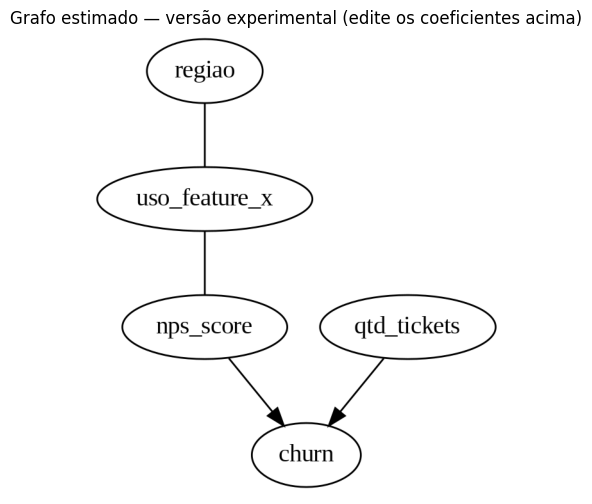

In [ ]:
# Roda o PC no dataset experimental e desenha o grafo
labels_exp = df_exp.columns.tolist()
data_exp = df_exp.values.astype(float)

cg_exp = pc(data_exp, alpha=0.05, indep_test=fisherz, node_names=labels_exp)

pyd_exp = GraphUtils.to_pydot(cg_exp.G, labels=labels_exp)
png_exp = pyd_exp.create_png(prog='dot')
img_exp = Image.open(io.BytesIO(png_exp))

plt.figure(figsize=(8, 6))
plt.imshow(img_exp)
plt.axis('off')
plt.title('Grafo estimado — versão experimental (edite os coeficientes acima)')
plt.show()


## Resumo do que essa POC prova (e não prova)

**Prova:**
- É possível, a partir de dados puramente observacionais, recuperar boa parte da
  estrutura causal real, incluindo pegar uma relação que o time humano tinha
  invertida (`qtd_tickets`).
- É possível estimar o tamanho do efeito, não só a direção, com DoWhy.

**Não prova (e é importante deixar isso claro pro seu chefe):**
- O algoritmo depende de você ter medido as variáveis certas (seção 7 mostrou isso).
- Relações fracas podem não ser detectadas com significância estatística.
- O resultado final ainda deveria ser validado com um experimento real (A/B test ou
  quase-experimento) antes de virar decisão de negócio definitiva — Causal Discovery
  aqui funciona como um **gerador de hipótese priorizada**, não como veredito final.
